# Iris Flower Prediction Project.

Welcome to the Iris Flower Prediction Project which will be a small application on training and testing a model.


### Introduction 

The Iris Flower Detection project uses the Iris dataset to classify flowers into three species: Setosa, Versicolor, and Virginica. The dataset includes 150 samples with four features: sepal length, sepal width, petal length, and petal width. This project demonstrates how machine learning techniques can be applied to build and evaluate a model for accurate species classification.


### Perparing the Environment 

In [1]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
# Load the dataset
data = datasets.load_iris()
# Convert to DataFrame for easier manipulation
df = pd.DataFrame(data.data, columns=data.feature_names)
df ['target'] = data.target
# Map target to species names
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

In [3]:
# Display the first few rows of the dataset
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


<Figure size 1000x1000 with 0 Axes>

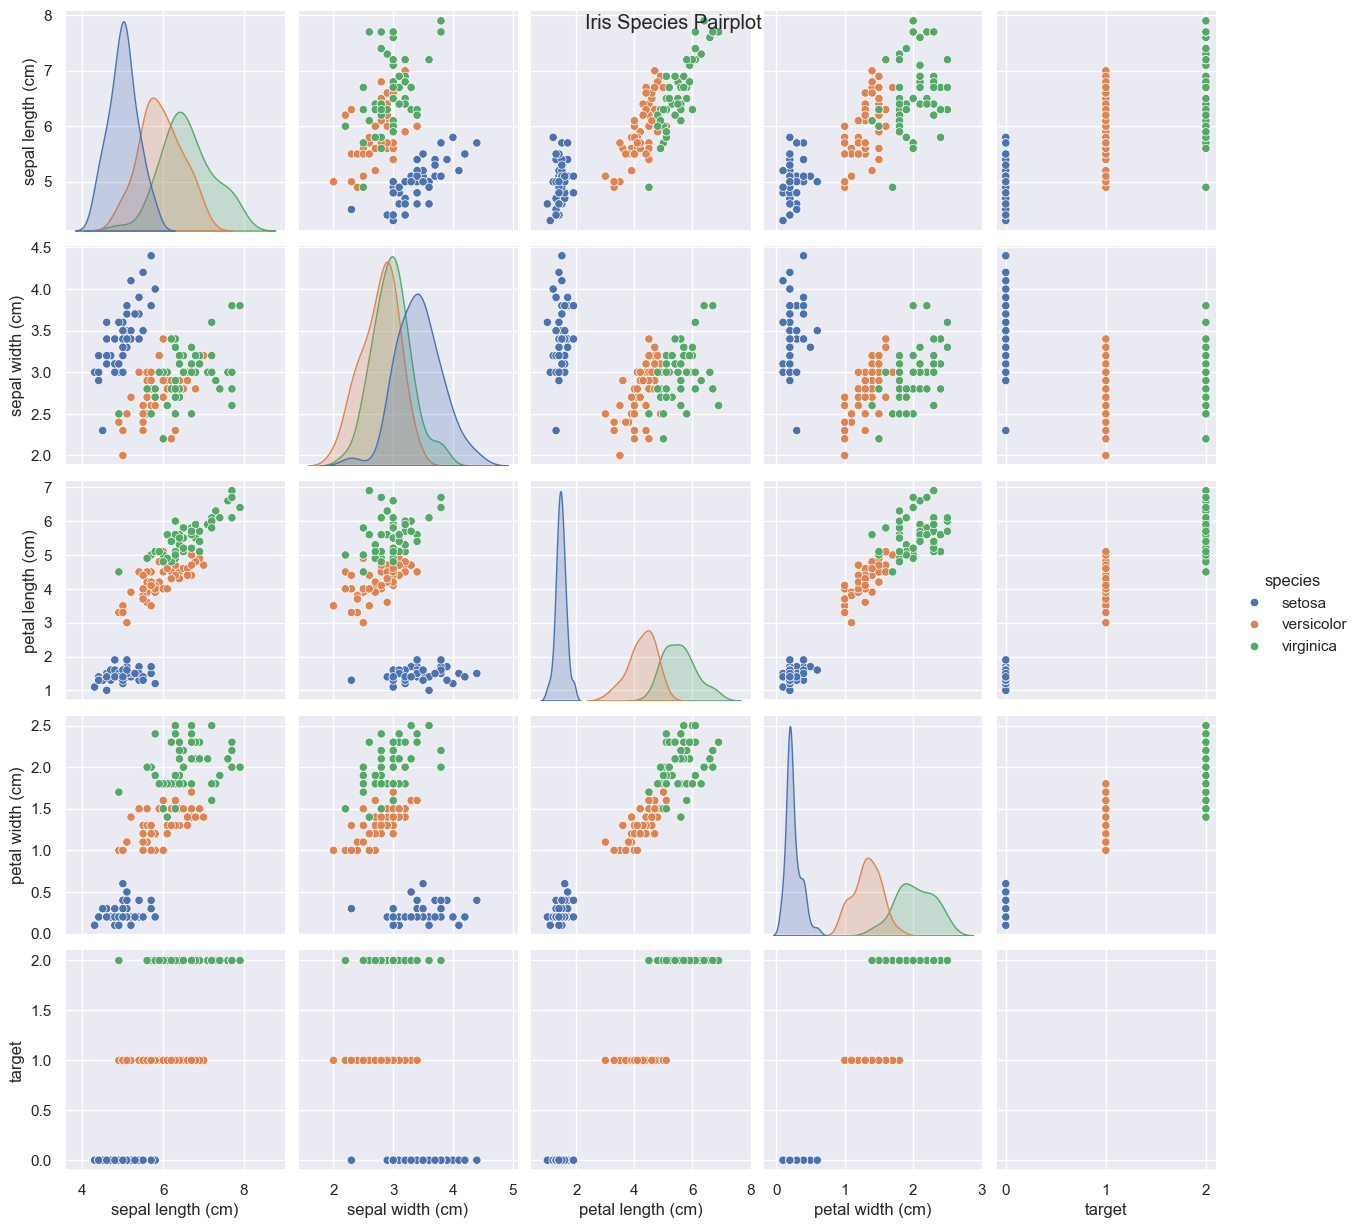

In [4]:
# Visualize the distribution of the target variable
sns.set()
plt.figure(figsize=(10, 10))
sns.pairplot(df, hue='species')
plt.suptitle('Iris Species Pairplot')
plt.show()


### Iris Species Pairplot 
The pairplot visualizes the relationships between the features of the Iris dataset, grouped by species.
It shows clear separations between species in certain feature combinations, such as petal length and petal width.
Setosa is distinctly separated from the other two species, while Versicolor and Virginica show some overlap.

In [5]:
# Split the dataset into features and target variable
X = df.drop(['target', 'species'], axis=1)  
y = df['target']
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=200, C=100)
# Fit the model to the training data
model.fit(X_train, y_train)
# Make predictions on the test set
y_pred = model.predict(X_test)
# Calculate the accuracy of the model
accuracy = model.score(X_test, y_test)
print(f'Accuracy: {accuracy:.3f}')


Accuracy: 1.000


In [6]:
manual_accuracy = np.mean(y_pred == y_test)
print (f' The manual accuracy is {manual_accuracy *100:.3f}%')

 The manual accuracy is 100.000%


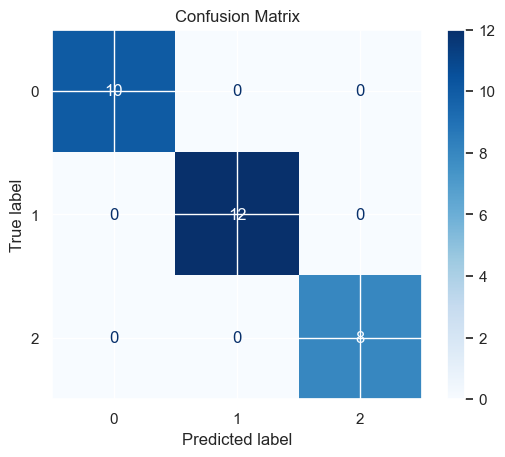

In [7]:
# Display the confusion matrix  
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

### Description of the Confusion Matrix
The confusion matrix visualizes the performance of the classification model.
Each row of the matrix represents the instances in an actual class, 
while each column represents the instances in a predicted class.
The diagonal elements indicate the number of correct predictions for each class.
Off-diagonal elements represent misclassifications.
A perfect model would have non-zero values only on the diagonal.


In [8]:
# Display classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=data.target_names))



              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        12
   virginica       1.00      1.00      1.00         8

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



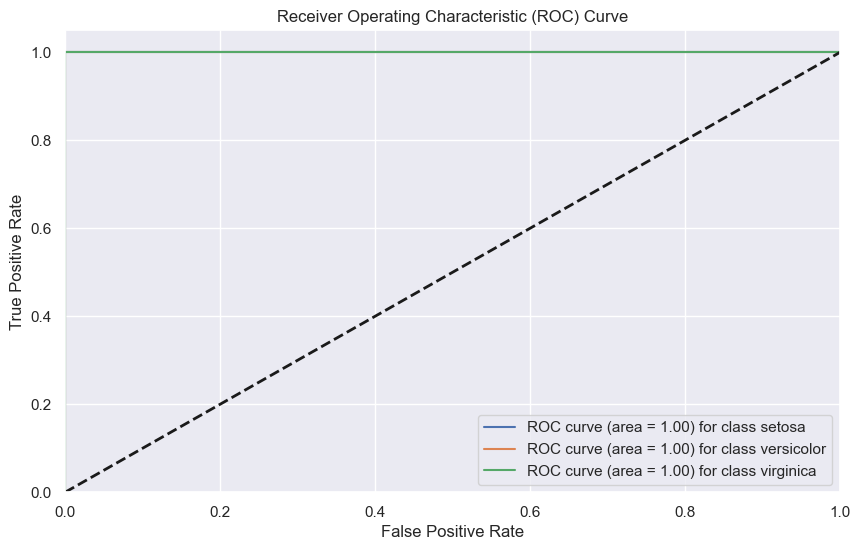

In [9]:
# Display ROC curve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
y_bin = label_binarize(y, classes=[0, 1, 2])
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], label_binarize(y_pred, classes=[0, 1, 2])[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
plt.figure(figsize=(10, 6))
for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve (area = {roc_auc[i]:.2f}) for class {data.target_names[i]}')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

### Description of the ROC Curve
The Receiver Operating Characteristic (ROC) curve is a graphical representation of a classifier's performance across different threshold values. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) for each class.
- The ROC curve helps evaluate the trade-off between sensitivity and specificity for different thresholds.
- It is particularly useful for multi-class classification problems, as it provides insights into the performance of the classifier for each class.
- The closer the curve is to the top-left corner, the better the classifier's performance for that class.
"""

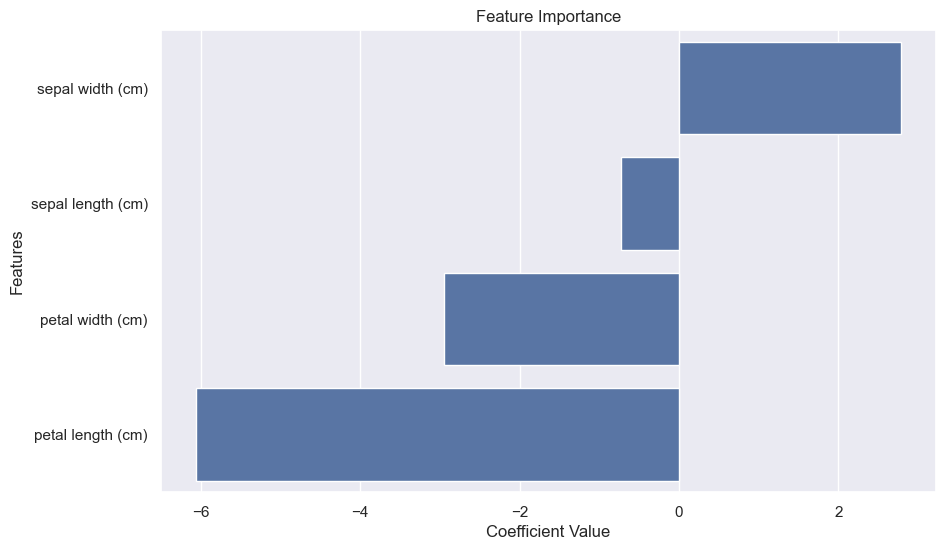

In [10]:
# Display feature importance
importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.coef_[0]})
importance = importance.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()



### Description of Feature Importance Graph
The graph displays the importance of each feature in the logistic regression model.
The importance is represented by the coefficients of the features.
Features with higher absolute coefficient values have a greater impact on the model's predictions.
Positive coefficients indicate a positive relationship with the target, while negative coefficients indicate a negative relationship.

In [11]:
# Display the first few rows of the dataset with predictions
df_test = X_test.copy()
df_test['Predicted'] = y_pred
df_test['Actual'] = y_test
df_test['Species'] = df_test['Actual'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df_test = df_test.reset_index(drop=True)
print(df_test.head())
# Save the model using joblib
import joblib
joblib.dump(model, 'logistic_regression_model.pkl')
# Load the model
loaded_model = joblib.load('logistic_regression_model.pkl')
# Make predictions with the loaded model
loaded_y_pred = loaded_model.predict(X_test)
# Check if the predictions are the same
assert np.array_equal(y_pred, loaded_y_pred), "Predictions do not match after loading the model."
print("Model loaded successfully and predictions match.")


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.8                1.6               0.2   
1                4.9               2.5                4.5               1.7   
2                6.1               2.8                4.7               1.2   
3                5.4               3.0                4.5               1.5   
4                5.0               3.4                1.6               0.4   

   Predicted  Actual     Species  
0          0       0      setosa  
1          2       2   virginica  
2          1       1  versicolor  
3          1       1  versicolor  
4          0       0      setosa  
Model loaded successfully and predictions match.


### Conclusion

The Iris Flower Prediction Project demonstrates the application of machine learning techniques to classify iris flowers into three species: Setosa, Versicolor, and Virginica. The project utilized the Iris dataset, which contains 150 samples with four features: sepal length, sepal width, petal length, and petal width.

Key steps and findings:
1. **Data Exploration and Visualization**: The dataset was visualized using pairplots to understand the relationships between features and the separability of species. Setosa was distinctly separable, while Versicolor and Virginica showed some overlap.
2. **Model Training and Evaluation**: A Logistic Regression model was trained on the dataset. The model achieved an accuracy of 100% on the test set, indicating excellent performance.
3. **Performance Metrics**: The confusion matrix and classification report provided insights into the model's performance, showing no misclassifications. The ROC curve further confirmed the model's ability to distinguish between classes effectively.
4. **Feature Importance**: The feature importance graph highlighted the contribution of each feature to the model's predictions, with petal length and petal width being the most significant.
5. **Model Persistence**: The trained model was saved and successfully reloaded, ensuring reproducibility and usability in future applications.

This project highlights the power of machine learning in solving classification problems and provides a foundation for further exploration of more complex datasets and models.
```